Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


##### Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/RTA Dataset.csv')

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


In [3]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns in dataset:")
print(df.columns.tolist())

Shape of dataset: (12316, 25)

First 5 rows:


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Vehicle_movement,Casualty_class,Sex_of_casualty,Cause_of_accident
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,Going straight,na,na,Moving Backward
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,Going straight,na,na,Overtaking
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,Going straight,Driver or rider,Male,Changing lane to the left
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Going straight,Pedestrian,Female,Changing lane to the right
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Going straight,na,na,Overtaking



Columns in dataset:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Cause_of_accident']


In [4]:
columns_to_drop = [
    'Age_band_of_driver',
    'Sex_of_driver',
    'Educational_level',
    'Vehicle_driver_relation',
    'Driving_experience',
    'Owner_of_vehicle',
    'Service_year_of_vehicle',
    'Sex_of_casualty',
    'Cause_of_accident',
    'Type_of_vehicle',
	'Defect_of_vehicle',
	'Road_allignment',
	'Road_surface_type',
	'Vehicle_movement',
]

# Drop only if they exist (safe)
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

Check data types

Check remaining columns to get all unique values

Overview

Check Missing Values

Visualize Missing Values

Remove Rows with Missing Target (Casualty_class + Type_of_collision + Number_of_vehicles_involved)

In [5]:
df.shape

(12316, 11)

In [6]:
# Count missing values per column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values

Time                             0
Day_of_week                      0
Area_accident_occured          239
Lanes_or_Medians               385
Types_of_Junction              887
Road_surface_conditions          0
Light_conditions                 0
Weather_conditions               0
Type_of_collision              155
Number_of_vehicles_involved      0
Casualty_class                   0
dtype: int64

In [7]:
# Replace all remaining NaN values
df = df.fillna("Unknown")

In [8]:
# Check again for missing values
df.isnull().sum()

Time                           0
Day_of_week                    0
Area_accident_occured          0
Lanes_or_Medians               0
Types_of_Junction              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Casualty_class                 0
dtype: int64

In [9]:
# Check cleaned dataset
df.head()

print("\nFinal Shape:", df.shape)
print("\nRemaining Columns:\n", df.columns.tolist())


Final Shape: (12316, 11)

Remaining Columns:
 ['Time', 'Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Casualty_class']


In [10]:
# Get combinations with counts
combinations = df.groupby(['Casualty_class', 
                           'Type_of_collision', 
                           'Number_of_vehicles_involved']).size().reset_index(name='Count')

# Sort by frequency (most common first)
combinations = combinations.sort_values(by='Count', ascending=False)

# Display all combinations
print(f"Total Unique Combinations: {len(combinations)}\n")
print(combinations.to_string(index=False))

Total Unique Combinations: 142

 Casualty_class                       Type_of_collision  Number_of_vehicles_involved  Count
Driver or rider          Vehicle with vehicle collision                            2   2321
             na          Vehicle with vehicle collision                            2   2141
     Pedestrian          Vehicle with vehicle collision                            2    816
      Passenger          Vehicle with vehicle collision                            2    624
Driver or rider          Vehicle with vehicle collision                            1    589
Driver or rider         Collision with roadside objects                            2    542
             na          Vehicle with vehicle collision                            1    505
Driver or rider          Vehicle with vehicle collision                            3    456
             na          Vehicle with vehicle collision                            3    441
             na         Collision with roadside 

In [11]:
# Create Risk Level 
def get_risk_level_manual(row):
    casualty = str(row['Casualty_class']).strip().lower() if pd.notna(row['Casualty_class']) else 'na'
    collision = str(row['Type_of_collision']).strip().lower() if pd.notna(row['Type_of_collision']) else ''
    vehicles = row['Number_of_vehicles_involved']
    
    try:
        vehicles = int(vehicles)
    except:
        vehicles = 2  # default
    
    # High Risk (H) - Based on your labeling
    if 'pedestrian' in casualty:
        return 'High'
    elif 'rollover' in collision or 'train' in collision:
        return 'High'
    elif vehicles >= 4:
        return 'High'
    elif casualty == 'na' and vehicles >= 3 and 'vehicle with vehicle' in collision:
        return 'High'
    elif 'collision with roadside objects' in collision and vehicles >= 2 and casualty in ['driver or rider', 'na']:
        return 'High'
    
    # Medium Risk (M)
    elif casualty == 'passenger':
        return 'Medium'
    elif vehicles == 3:
        return 'Medium'
    elif 'vehicle with vehicle' in collision and vehicles == 2 and casualty == 'na':
        return 'Medium'
    elif 'roadside' in collision and vehicles == 2:
        return 'Medium'
    elif casualty == 'driver or rider' and vehicles == 1:
        return 'Medium'
    
    # Low Risk (L) - Default for safer cases
    else:
        return 'Low'

# Apply the function
df['Risk_Level'] = df.apply(get_risk_level_manual, axis=1)

# Check final distribution
print("Final Risk Level Distribution:")
print(df['Risk_Level'].value_counts())
print("\nPercentage:")
print(round(df['Risk_Level'].value_counts(normalize=True) * 100, 2))

Final Risk Level Distribution:
Risk_Level
Medium    4724
High      3924
Low       3668
Name: count, dtype: int64

Percentage:
Risk_Level
Medium    38.36
High      31.86
Low       29.78
Name: proportion, dtype: float64


In [12]:
# Count missing values per column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values

Time                           0
Day_of_week                    0
Area_accident_occured          0
Lanes_or_Medians               0
Types_of_Junction              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Casualty_class                 0
Risk_Level                     0
dtype: int64

##### remove unwanted features

In [13]:
df = df.drop(columns=['Type_of_collision', 'Number_of_vehicles_involved', 'Casualty_class'])

##### convert time to morning, afternoon, evening and night

In [14]:
df.head()

,Time,Day_of_week,Area_accident_occured,Lanes_or_Medians,Types_of_Junction,Road_surface_conditions,Light_conditions,Weather_conditions,Risk_Level
0,17:02:00,Monday,Residential areas,Unknown,No junction,Dry,Daylight,Normal,Medium
1,17:02:00,Monday,Office areas,Undivided Two way,No junction,Dry,Daylight,Normal,Medium
2,17:02:00,Monday,Recreational areas,other,No junction,Dry,Daylight,Normal,High
3,01:06:00,Sunday,Office areas,other,Y Shape,Dry,Darkness - lights lit,Normal,High
4,01:06:00,Sunday,Industrial areas,other,Y Shape,Dry,Darkness - lights lit,Normal,Medium


##### Time into categories

In [15]:
# === SIMPLIFY TIME ONLY (without removing other features) ===

# Create Hour from Time
df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

# Create Time Period (Low cardinality - only 4 categories)
def get_time_period(hour):
    if pd.isna(hour):
        return "Unknown"
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Time_Period'] = df['Hour'].apply(get_time_period)

# Drop original Time if you were using it
if 'Time' in df.columns:
    df = df.drop(columns=['Time'])

print("Time simplified successfully!")
print(df[['Hour', 'Time_Period']].head())

Time simplified successfully!
   Hour Time_Period
0    17     Evening
1    17     Evening
2    17     Evening
3     1       Night
4     1       Night


In [16]:
df.head()

,Day_of_week,Area_accident_occured,Lanes_or_Medians,Types_of_Junction,Road_surface_conditions,Light_conditions,Weather_conditions,Risk_Level,Hour,Time_Period
0,Monday,Residential areas,Unknown,No junction,Dry,Daylight,Normal,Medium,17,Evening
1,Monday,Office areas,Undivided Two way,No junction,Dry,Daylight,Normal,Medium,17,Evening
2,Monday,Recreational areas,other,No junction,Dry,Daylight,Normal,High,17,Evening
3,Sunday,Office areas,other,Y Shape,Dry,Darkness - lights lit,Normal,High,1,Night
4,Sunday,Industrial areas,other,Y Shape,Dry,Darkness - lights lit,Normal,Medium,1,Night


##### Feature Selection & Target

In [17]:
# Features to use 
feature_columns = [
    'Day_of_week', 'Area_accident_occured',
    'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_conditions',
    'Light_conditions', 'Weather_conditions', 'Hour', 'Time_Period'
    
]

X = df[feature_columns].copy()
y = df['Risk_Level']

print("Selected features:", X.columns.tolist())

Selected features: ['Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Hour', 'Time_Period']


In [18]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

le = LabelEncoder()
y_encoded = le.fit_transform(y)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)

print("Processed Shape:", X_processed.shape)

Processed Shape: (12316, 58)


In [19]:
print(le.classes_)

['High' 'Low' 'Medium']


In [20]:
X_processed

array([[ 0.,  1.,  0., ...,  0.,  0., 17.],
       [ 0.,  1.,  0., ...,  0.,  0., 17.],
       [ 0.,  1.,  0., ...,  0.,  0., 17.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0., 13.],
       [ 0.,  0.,  0., ...,  0.,  0., 13.],
       [ 0.,  0.,  0., ...,  0.,  0., 13.]], shape=(12316, 58))

In [21]:
# First 2 rows of your selected features (before encoding)
print("=== First 2 Rows - Original Features ===")
display(X.head(10))        # Nice formatted view in Jupyter

=== First 2 Rows - Original Features ===


,Day_of_week,Area_accident_occured,Lanes_or_Medians,Types_of_Junction,Road_surface_conditions,Light_conditions,Weather_conditions,Hour,Time_Period
0,Monday,Residential areas,Unknown,No junction,Dry,Daylight,Normal,17,Evening
1,Monday,Office areas,Undivided Two way,No junction,Dry,Daylight,Normal,17,Evening
2,Monday,Recreational areas,other,No junction,Dry,Daylight,Normal,17,Evening
3,Sunday,Office areas,other,Y Shape,Dry,Darkness - lights lit,Normal,1,Night
4,Sunday,Industrial areas,other,Y Shape,Dry,Darkness - lights lit,Normal,1,Night
5,Friday,Unknown,Unknown,Y Shape,Dry,Daylight,Normal,14,Afternoon
6,Wednesday,Residential areas,Undivided Two way,Crossing,Dry,Daylight,Normal,17,Evening
7,Friday,Residential areas,other,Y Shape,Dry,Daylight,Normal,17,Evening
8,Friday,Industrial areas,other,Y Shape,Dry,Daylight,Normal,17,Evening
9,Friday,Residential areas,Undivided Two way,Y Shape,Dry,Daylight,Normal,17,Evening


In [22]:
print("=== First 2 Rows - After One-Hot Encoding ===")
print(X_processed[0:10])

# To see it better as DataFrame (with column names if possible)
# Note: Column names after one-hot are a bit messy, but useful for checking
feature_names = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed[:10], columns=feature_names)

print("\nFirst 2 rows with column names:")
display(X_processed_df)

=== First 2 Rows - After One-Hot Encoding ===
[[ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.
   1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.
   1.  0.  0. 17.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.
   1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.
   1.  0.  0. 17.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.
   1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.
   1.  0.  0. 17.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  1.
   1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.
   0.  0.

,cat__Day_of_week_Friday,cat__Day_of_week_Monday,cat__Day_of_week_Saturday,cat__Day_of_week_Sunday,cat__Day_of_week_Thursday,cat__Day_of_week_Tuesday,cat__Day_of_week_Wednesday,cat__Area_accident_occured_ Market areas,cat__Area_accident_occured_ Recreational areas,cat__Area_accident_occured_ Church areas,...,cat__Weather_conditions_Raining,cat__Weather_conditions_Raining and Windy,cat__Weather_conditions_Snow,cat__Weather_conditions_Unknown,cat__Weather_conditions_Windy,cat__Time_Period_Afternoon,cat__Time_Period_Evening,cat__Time_Period_Morning,cat__Time_Period_Night,remainder__Hour
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,14.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.0


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9852, 58)
Test shape: (2464, 58)


=== Training Set Class Distribution ===
2    3779
0    3139
1    2934
Name: count, dtype: int64

Percentage in Training Set:
2    38.36
0    31.86
1    29.78
Name: count, dtype: float64


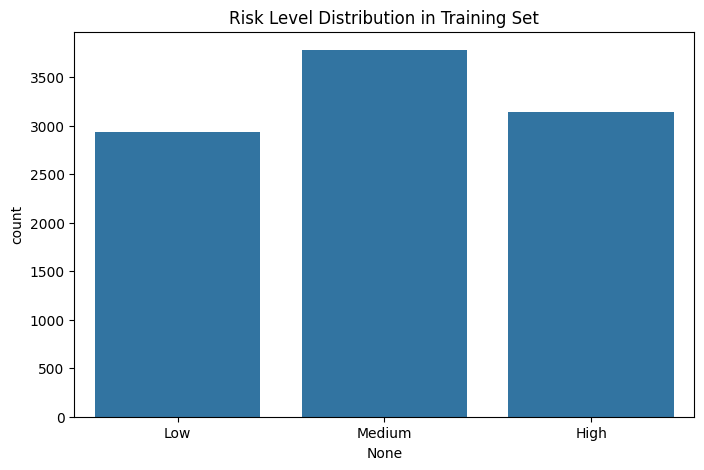

In [24]:
# Check balance in Training set
print("=== Training Set Class Distribution ===")
train_dist = pd.Series(y_train).value_counts()
print(train_dist)

print("\nPercentage in Training Set:")
print(round(train_dist / len(y_train) * 100, 2))

# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=pd.Series(le.inverse_transform(y_train)), 
              order=['Low', 'Medium', 'High'])
plt.title('Risk Level Distribution in Training Set')
plt.show()

In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(1.0461930551130934), 1: np.float64(1.1192910702113157), 2: np.float64(0.8690129663932257)}


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout

# Stronger Model
model = Sequential([
    # Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    # BatchNormalization(),
    # Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    
    Dense(32, activation='relu'),
    Dropout(0.05),

    Dense(16, activation='relu'),
    Dropout(0.05),

    # Dense(8, activation='relu'),
    # Dropout(0.025),
    
    Dense(len(le.classes_), activation='softmax')
])

optimizer = Adam(learning_rate=0.00008)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3387 - loss: 1.1801 - val_accuracy: 0.3394 - val_loss: 1.1093 - learning_rate: 8.0000e-05
Epoch 2/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3401 - loss: 1.1488 - val_accuracy: 0.3420 - val_loss: 1.1104 - learning_rate: 8.0000e-05
Epoch 3/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3359 - loss: 1.1308 - val_accuracy: 0.3465 - val_loss: 1.1143 - learning_rate: 8.0000e-05
Epoch 4/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3349 - loss: 1.1259 - val_accuracy: 0.3389 - val_loss: 1.1117 - learning_rate: 8.0000e-05
Epoch 5/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3321 - loss: 1.1174 - val_accuracy: 0.3486 - val_loss: 1.1090 - learning_rate: 8.0000e-05
Epoch 6/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3441 - loss: 1.1156 - val_accuracy: 0.3374 - val_loss: 1.1094 - learning_rate: 8.0000e-05
Epoch 7/150
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step
=== Classification Report ===
              precision    recall  f1-score   support

        High       0.32      0.45      0.38       785
         Low       0.29      0.26      0.28       734
      Medium       0.41      0.30      0.35       945

    accuracy                           0.34      2464
   macro avg       0.34      0.34      0.33      2464
weighted avg       0.35      0.34      0.34      2464



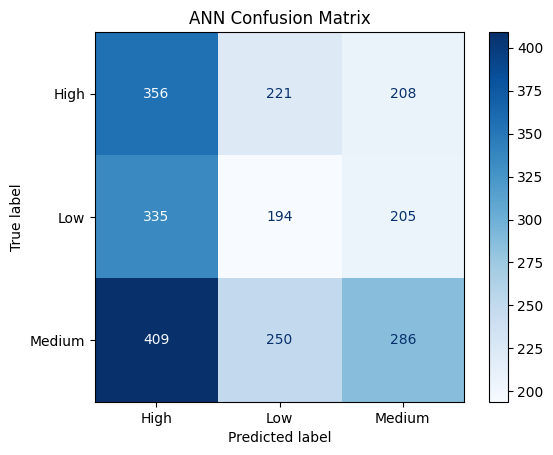

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('ANN Confusion Matrix')
plt.show()

In [28]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.3392857015132904
